In [ ]:
import shutil, os

# Source path for the dataset.zip
zip_path_to_copy = "/content/dataset.zip"

# Destination folder in Google Drive
drive_folder = "/content/drive/MyDrive/MultiClinNER-XLMR"

# Create folder if it doesn't exist
os.makedirs(drive_folder, exist_ok=True)

# Copy
dest_path = os.path.join(drive_folder, os.path.basename(zip_path_to_copy))
print(f"Copying {zip_path_to_copy} to {dest_path} ...")
shutil.copy2(zip_path_to_copy, dest_path)

size_mb = os.path.getsize(dest_path) / 1024**2
print(f"✅ Done! {dest_path}  ({size_mb:.1f} MB)")

Copying /content/dataset.zip to /content/drive/MyDrive/MultiClinNER-XLMR/dataset.zip ...
✅ Done! /content/drive/MyDrive/MultiClinNER-XLMR/dataset.zip  (2964.2 MB)


In [ ]:
# Download the dataset
# The URL is extracted from cell 8BFxxAkZ94w7
dataset_url = "https://zenodo.org/records/19334278/files/MultiClinAI-training+NER_test_bg+CORPUS_test_bg_v1.3_260330.zip?download=1"
!wget "{dataset_url}" -O dataset.zip

--2026-05-29 15:47:29--  https://zenodo.org/records/19334278/files/MultiClinAI-training+NER_test_bg+CORPUS_test_bg_v1.3_260330.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.184.103.118, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3108231547 (2.9G) [application/octet-stream]
Saving to: ‘dataset.zip’

dataset.zip         100%[===================>]   2.89G  22.6MB/s    in 53s     

2026-05-29 15:48:22 (56.4 MB/s) - ‘dataset.zip’ saved [3108231547/3108231547]



In [ ]:
import os, zipfile, threading
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm

zip_path = "dataset.zip"
dataset_output_dir = "/dev/shm/dataset"   # RAM disk
os.makedirs(dataset_output_dir, exist_ok=True)

thread_local = threading.local()

def get_zf():
    if not hasattr(thread_local, 'zf'):
        thread_local.zf = zipfile.ZipFile(zip_path, 'r')
    return thread_local.zf

def extract_batch(batch):
    zf = get_zf()
    for member in batch:
        zf.extract(member, dataset_output_dir)
    return len(batch)

with zipfile.ZipFile(zip_path, 'r') as zf:
    members = zf.namelist()

total = len(members)
n_workers = os.cpu_count()
batch_size = max(1000, total // (n_workers * 10))
batches = [members[i:i+batch_size] for i in range(0, total, batch_size)]

print(f"📦 Extracting {total} files to RAM...")

with ThreadPoolExecutor(max_workers=n_workers) as executor:
    with tqdm(total=total, unit="file", unit_scale=True) as pbar:
        for count in executor.map(extract_batch, batches):
            pbar.update(count)

print(f"✅ Done → {dataset_output_dir}")

In [ ]:
import shutil

source_dir = '/content/drive/MyDrive/MultiClinNER-XLMR'
destination_dir = '/content/MultiClinNER-XLMR'

# Ensure the destination directory exists
import os
if not os.path.exists(destination_dir):
    os.makedirs(destination_dir)

try:
    shutil.move(source_dir, destination_dir)
    print(f"Successfully moved '{source_dir}' to '{destination_dir}'.")
except Exception as e:
    print(f"Error moving directory: {e}")

Successfully moved '/content/drive/MyDrive/MultiClinNER-XLMR' to '/content/MultiClinNER-XLMR'.


In [ ]:
import sys
import os
from pathlib import Path

REPO_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
sys.path.insert(0, str(REPO_ROOT / 'src'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_from_disk
from transformers import DataCollatorForTokenClassification, Trainer, TrainingArguments

from dataset import id2label
from model import load_model, compute_metrics, compute_class_weights, WeightedLossTrainer
from utils import tokenizer

OUTPUT_DIR   = REPO_ROOT / 'outputs' / 'checkpoints'
RESULTS_DIR  = REPO_ROOT / 'outputs' / 'results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING  : No GPU detected — training will be slow')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

PyTorch  : 2.11.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB


In [ ]:
cd MultiClinNER-XLMR/


/content/MultiClinNER-XLMR


In [ ]:
ls

 Class-Project-Proposal-24K7606.pdf
 CLAUDE.md
 data/
 MultiClinAI-training+NER_test_bg+CORPUS_test_bg_v1.3_260330/
 MultiClinNER_XLM-R.ipynb
 notebooks/
 outputs/
'Paper-Unsupervised Cross-lingual Representation Learning at Scale.pdf'
 prepare_data.py
 README.md
 requirements.txt
 src/
 todo.txt


In [ ]:
cd MUl

drive/  MultiClinNER-XLMR/  sample_data/


In [ ]:
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed' / 'joint'
if not PROCESSED_DIR.exists():
    raise FileNotFoundError(
        f'Processed dataset not found at {PROCESSED_DIR}.\n'
        'Run notebooks/02_preprocessing.ipynb first.'
    )

joint_ds = load_from_disk(str(PROCESSED_DIR))
print('Dataset loaded:')
print(joint_ds)
print(f'\nTrain size : {len(joint_ds["train"])} sentences')
print(f'Dev size   : {len(joint_ds["validation"])} sentences')

model = load_model('xlm-roberta-base')
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel      : xlm-roberta-base')
print(f'Parameters : {total_params:,} total  |  {trainable:,} trainable')

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

Dataset loaded:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 20163
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2315
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2250
    })
})

Train size : 20163 sentences
Dev size   : 2315 sentences


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model      : xlm-roberta-base
Parameters : 277,458,439 total  |  277,458,439 trainable


In [ ]:
USE_FP16   = torch.cuda.is_available()
# T4 16 GB: batch=32 fp16 uses ~6 GB total — no accumulation needed.
BATCH_SIZE = 32
GRAD_ACCUM = 1
NUM_EPOCHS = 5

total_steps  = (len(joint_ds['train']) // (BATCH_SIZE * GRAD_ACCUM)) * NUM_EPOCHS
warmup_steps = int(total_steps * 0.1)

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    # AdamW fits in 16 GB and gives better convergence than Adafactor.
    # Adafactor was only needed for the 3.9 GB Quadro T1000.
    optim='adamw_torch',
    # T4 has enough VRAM to store all activations; disabling checkpointing
    # saves ~25% compute by not recomputing activations during backward pass.
    gradient_checkpointing=False,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='overall_f1',
    greater_is_better=True,
    fp16=USE_FP16,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    logging_steps=50,
    report_to='none',
    seed=42,
)

steps_per_epoch = len(joint_ds['train']) // (BATCH_SIZE * GRAD_ACCUM)
print(f'Effective batch : {BATCH_SIZE * GRAD_ACCUM}')
print(f'Steps per epoch : ~{steps_per_epoch}')
print(f'Total steps     : ~{steps_per_epoch * NUM_EPOCHS}')
print(f'Warmup steps    : {warmup_steps}')
print(f'Mixed precision : {USE_FP16}')

Effective batch : 32
Steps per epoch : ~630
Total steps     : ~3150
Warmup steps    : 315
Mixed precision : True


In [ ]:
# Compute per-class weights to counteract O-label dominance (~93% of tokens are O).
# Without weighting, the model collapses to predicting O for everything (F1 ≈ 0).
class_weights = compute_class_weights(joint_ds['train'])
print('Class weights:')
for i, w in enumerate(class_weights.tolist()):
    print(f'  {id2label[i]:<8} {w:.3f}')

trainer = WeightedLossTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=joint_ds['train'],
    eval_dataset=joint_ds['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('\nStarting training ...')
trainer.train()

best_model_path = OUTPUT_DIR / 'best_model'
trainer.save_model(str(best_model_path))
print(f'\nBest model saved to {best_model_path}')

Class weights:
  O        0.163
  B-DIS    10.272
  I-DIS    5.269
  B-SYM    9.424
  I-SYM    4.436
  B-PRO    10.374
  I-PRO    6.715

Starting training ...


Epoch,Training Loss,Validation Loss,Precision,Recall,Overall F1
1,0.687260,0.656577,0.136002,0.617057,0.222880
2,0.572495,0.606586,0.145340,0.651501,0.237662
3,0.492200,0.629752,0.153655,0.670289,0.250000
4,0.449932,0.623382,0.169279,0.700313,0.272652
5,0.397774,0.628550,0.170823,0.696445,0.274353


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Best model saved to /content/MultiClinNER-XLMR/outputs/checkpoints/best_model


Saved: /content/MultiClinNER-XLMR/outputs/results/training_curves.png


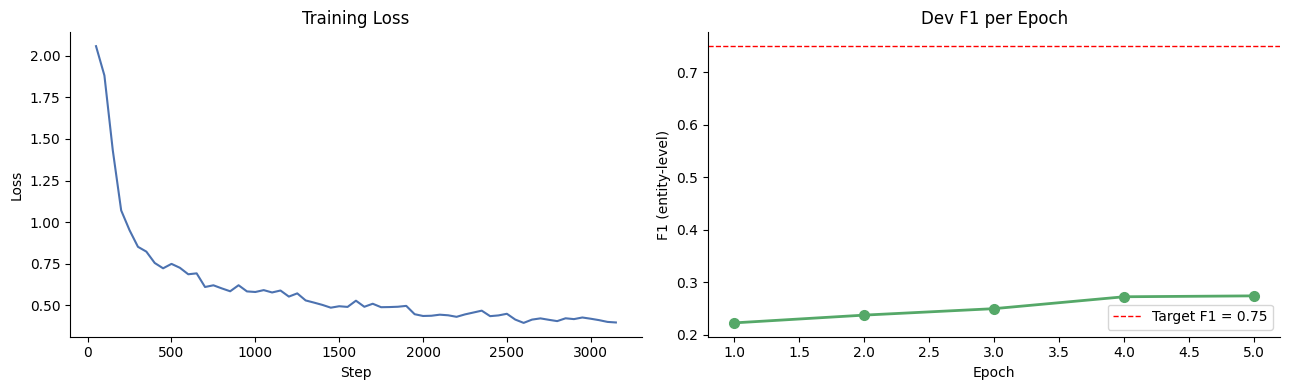


Best dev F1 : 0.2744  (epoch 5)


In [ ]:
log_history = pd.DataFrame(trainer.state.log_history)

train_log = log_history.dropna(subset=['loss']).copy()
eval_log  = log_history.dropna(subset=['eval_overall_f1']).copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(train_log['step'], train_log['loss'], color='#4C72B0', linewidth=1.5)
ax1.set(xlabel='Step', ylabel='Loss', title='Training Loss')
ax1.spines[['top', 'right']].set_visible(False)

ax2.plot(eval_log['epoch'], eval_log['eval_overall_f1'],
         marker='o', color='#55A868', linewidth=2, markersize=7)
ax2.axhline(0.75, color='red', linestyle='--', linewidth=1, label='Target F1 = 0.75')
ax2.set(xlabel='Epoch', ylabel='F1 (entity-level)', title='Dev F1 per Epoch')
ax2.legend()
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
curve_path = RESULTS_DIR / 'training_curves.png'
plt.savefig(str(curve_path), dpi=150, bbox_inches='tight')
print(f'Saved: {curve_path}')
plt.show()

best_f1 = eval_log['eval_overall_f1'].max()
best_ep = eval_log.loc[eval_log['eval_overall_f1'].idxmax(), 'epoch']
print(f'\nBest dev F1 : {best_f1:.4f}  (epoch {best_ep:.0f})')

In [ ]:
from seqeval.metrics import classification_report

preds_out   = trainer.predict(joint_ds['validation'])
logits, labels = preds_out.predictions, preds_out.label_ids
predictions = np.argmax(logits, axis=2)

true_labels = [[id2label[l] for l in seq if l != -100] for seq in labels]
true_preds  = [[id2label[p] for (p, l) in zip(ps, ls) if l != -100]
               for ps, ls in zip(predictions, labels)]

print('=== Dev set results (EN) ===')
print(classification_report(true_labels, true_preds))

=== Dev set results (EN) ===
              precision    recall  f1-score   support

         DIS       0.20      0.69      0.30      1997
         PRO       0.15      0.73      0.25      1588
         SYM       0.17      0.68      0.27      1844

   micro avg       0.17      0.70      0.27      5429
   macro avg       0.17      0.70      0.27      5429
weighted avg       0.17      0.70      0.28      5429



In [ ]:
#evaluation 04

In [ ]:
import sys
import os
from pathlib import Path

REPO_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
sys.path.insert(0, str(REPO_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from datasets import load_from_disk
from transformers import (
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    Trainer,
)
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix

from dataset import id2label, LABEL_LIST
from utils import tokenizer

BEST_MODEL_PATH = REPO_ROOT / 'outputs' / 'checkpoints' / 'best_model'
RESULTS_DIR     = REPO_ROOT / 'outputs' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f'Best model not found at {BEST_MODEL_PATH}.\n'
        'Complete Phase 4 training first.'
    )
print(f'Model path : {BEST_MODEL_PATH}')
print(f'Results dir: {RESULTS_DIR}')

Model path : /content/MultiClinNER-XLMR/outputs/checkpoints/best_model
Results dir: /content/MultiClinNER-XLMR/outputs/results


In [ ]:
model = AutoModelForTokenClassification.from_pretrained(str(BEST_MODEL_PATH))
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    processing_class=tokenizer,
    data_collator=data_collator,
)


def predict_on_split(lang, split='test'):
    """Run inference and return (true_labels, true_preds) as BIO string lists."""
    ds = load_from_disk(str(REPO_ROOT / 'data' / 'processed' / lang))
    preds_out = trainer.predict(ds[split])
    logits, labels = preds_out.predictions, preds_out.label_ids
    predictions = np.argmax(logits, axis=2)
    true_labels = [
        [id2label[l] for l in seq if l != -100]
        for seq in labels
    ]
    true_preds = [
        [id2label[p] for (p, l) in zip(ps, ls) if l != -100]
        for ps, ls in zip(predictions, labels)
    ]
    return true_labels, true_preds


print('Model loaded. Ready for evaluation.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded. Ready for evaluation.


In [ ]:
print('Running inference on EN test set ...')
en_true, en_pred = predict_on_split('en', 'test')

print('\n=== English Test Results ===')
print(classification_report(en_true, en_pred))

en_report = classification_report(en_true, en_pred, output_dict=True)

# Build a readable per-entity table
en_rows = []
for entity in ['DIS', 'SYM', 'PRO']:
    row = en_report.get(entity, {})
    en_rows.append({
        'Entity': entity,
        'Precision': round(row.get('precision', 0), 4),
        'Recall':    round(row.get('recall',    0), 4),
        'F1':        round(row.get('f1-score',  0), 4),
        'Support':   int(row.get('support',     0)),
    })
en_df = pd.DataFrame(en_rows)
en_overall_f1 = f1_score(en_true, en_pred)
print(f'\nOverall entity F1 (EN): {en_overall_f1:.4f}')
en_df

Running inference on EN test set ...



=== English Test Results ===
              precision    recall  f1-score   support

         DIS       0.22      0.67      0.33      2204
         PRO       0.15      0.72      0.25      1620
         SYM       0.15      0.66      0.25      1789

   micro avg       0.17      0.68      0.28      5613
   macro avg       0.17      0.69      0.28      5613
weighted avg       0.18      0.68      0.28      5613


Overall entity F1 (EN): 0.2761


,Entity,Precision,Recall,F1,Support
0,DIS,0.2155,0.6733,0.3265,2204
1,SYM,0.1532,0.6635,0.2490,1789
2,PRO,0.1544,0.7216,0.2544,1620


In [ ]:
print('Running inference on ES test set ...')
es_true, es_pred = predict_on_split('es', 'test')

print('\n=== Spanish Test Results ===')
print(classification_report(es_true, es_pred))

es_report = classification_report(es_true, es_pred, output_dict=True)

es_rows = []
for entity in ['DIS', 'SYM', 'PRO']:
    row = es_report.get(entity, {})
    es_rows.append({
        'Entity': entity,
        'Precision': round(row.get('precision', 0), 4),
        'Recall':    round(row.get('recall',    0), 4),
        'F1':        round(row.get('f1-score',  0), 4),
        'Support':   int(row.get('support',     0)),
    })
es_df = pd.DataFrame(es_rows)
es_overall_f1 = f1_score(es_true, es_pred)
print(f'\nOverall entity F1 (ES): {es_overall_f1:.4f}')
es_df

Running inference on ES test set ...



=== Spanish Test Results ===
              precision    recall  f1-score   support

         DIS       0.20      0.69      0.31      1837
         PRO       0.20      0.74      0.31      1872
         SYM       0.15      0.66      0.25      1655

   micro avg       0.18      0.70      0.29      5364
   macro avg       0.18      0.70      0.29      5364
weighted avg       0.18      0.70      0.29      5364


Overall entity F1 (ES): 0.2892


,Entity,Precision,Recall,F1,Support
0,DIS,0.2010,0.6908,0.3114,1837
1,SYM,0.1527,0.6634,0.2483,1655
2,PRO,0.1956,0.7393,0.3094,1872


In [ ]:
def extract_f1(report_dict, entity):
    return round(report_dict.get(entity, {}).get('f1-score', float('nan')), 4)

comparison_data = [
    {
        'Model':      'mBERT',
        'Language':   'EN',
        'DIS F1':     '—',
        'SYM F1':     '—',
        'PRO F1':     '—',
        'Overall F1': '— (run mBERT baseline)',
    },
    {
        'Model':      'mBERT',
        'Language':   'ES',
        'DIS F1':     '—',
        'SYM F1':     '—',
        'PRO F1':     '—',
        'Overall F1': '— (run mBERT baseline)',
    },
    {
        'Model':      'XLM-R (joint)',
        'Language':   'EN',
        'DIS F1':     extract_f1(en_report, 'DIS'),
        'SYM F1':     extract_f1(en_report, 'SYM'),
        'PRO F1':     extract_f1(en_report, 'PRO'),
        'Overall F1': round(en_overall_f1, 4),
    },
    {
        'Model':      'XLM-R (joint)',
        'Language':   'ES',
        'DIS F1':     extract_f1(es_report, 'DIS'),
        'SYM F1':     extract_f1(es_report, 'SYM'),
        'PRO F1':     extract_f1(es_report, 'PRO'),
        'Overall F1': round(es_overall_f1, 4),
    },
]

comp_df = pd.DataFrame(comparison_data)
print('Model comparison table (mBERT rows require separate training run):')
comp_df

Model comparison table (mBERT rows require separate training run):


,Model,Language,DIS F1,SYM F1,PRO F1,Overall F1
0,mBERT,EN,—,—,—,— (run mBERT baseline)
1,mBERT,ES,—,—,—,— (run mBERT baseline)
2,XLM-R (joint),EN,0.3265,0.249,0.2544,0.2761
3,XLM-R (joint),ES,0.3114,0.2483,0.3094,0.2892


Saved: /content/MultiClinNER-XLMR/outputs/results/confusion_matrix_en.png


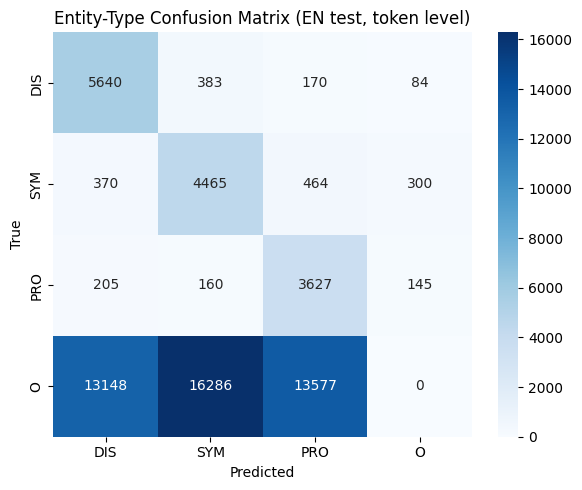

In [ ]:
def flatten_entity_tokens(true_seqs, pred_seqs):
    """Return flat lists of (true, pred) labels for non-O tokens only."""
    flat_true, flat_pred = [], []
    for ts, ps in zip(true_seqs, pred_seqs):
        for t, p in zip(ts, ps):
            if t != 'O' or p != 'O':  # include any token where true or pred is an entity
                # Normalise B-/I- prefix for confusion matrix (focus on type, not boundary)
                t_type = t[2:] if t != 'O' else 'O'
                p_type = p[2:] if p != 'O' else 'O'
                flat_true.append(t_type)
                flat_pred.append(p_type)
    return flat_true, flat_pred


en_ft, en_fp = flatten_entity_tokens(en_true, en_pred)
entity_labels = ['DIS', 'SYM', 'PRO', 'O']
cm = confusion_matrix(en_ft, en_fp, labels=entity_labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=entity_labels,
    yticklabels=entity_labels,
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Entity-Type Confusion Matrix (EN test, token level)')
plt.tight_layout()
cm_path = RESULTS_DIR / 'confusion_matrix_en.png'
plt.savefig(str(cm_path), dpi=150, bbox_inches='tight')
print(f'Saved: {cm_path}')
plt.show()

In [ ]:
import json
import numpy as np

def convert_numpy_types(obj):
    if isinstance(obj, dict):
        return {k: convert_numpy_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_types(elem) for elem in obj]
    elif isinstance(obj, np.int64):
        return int(obj)
    elif isinstance(obj, np.float64):
        return float(obj)
    return obj

en_report_serializable = convert_numpy_types(en_report)
es_report_serializable = convert_numpy_types(es_report)

with open(RESULTS_DIR / 'en_test_results.json', 'w') as f:
    json.dump(en_report_serializable, f, indent=2)
with open(RESULTS_DIR / 'es_test_results.json', 'w') as f:
    json.dump(es_report_serializable, f, indent=2)

print(f'EN results saved → {RESULTS_DIR / "en_test_results.json"}')
print(f'ES results saved → {RESULTS_DIR / "es_test_results.json"}')

EN results saved → /content/MultiClinNER-XLMR/outputs/results/en_test_results.json
ES results saved → /content/MultiClinNER-XLMR/outputs/results/es_test_results.json


In [ ]:
#os error analysis 05

In [ ]:
import sys
import os
from pathlib import Path

REPO_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
sys.path.insert(0, str(REPO_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_from_disk
from transformers import (
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    Trainer,
)

from dataset import id2label, load_conll
from utils import tokenizer, get_data_paths

BEST_MODEL_PATH = REPO_ROOT / 'outputs' / 'checkpoints' / 'best_model'

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f'Best model not found at {BEST_MODEL_PATH}.\n'
        'Complete Phase 4 training first.'
    )

model = AutoModelForTokenClassification.from_pretrained(str(BEST_MODEL_PATH))
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    processing_class=tokenizer,
    data_collator=data_collator,
)

print('Model loaded.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded.


In [ ]:
def get_predictions(lang, split='test'):
    """Return (sentences, true_labels, true_preds) for a language split."""
    train_f, dev_f, test_f = get_data_paths(lang)
    split_file = {'train': train_f, 'validation': dev_f, 'test': test_f}[split]
    sentences = load_conll(split_file)

    ds = load_from_disk(str(REPO_ROOT / 'data' / 'processed' / lang))
    preds_out = trainer.predict(ds[split])
    logits, labels = preds_out.predictions, preds_out.label_ids
    predictions = np.argmax(logits, axis=2)

    true_labels = [
        [id2label[l] for l in seq if l != -100]
        for seq in labels
    ]
    true_preds = [
        [id2label[p] for (p, l) in zip(ps, ls) if l != -100]
        for ps, ls in zip(predictions, labels)
    ]
    return sentences, true_labels, true_preds


def collect_errors(sentences, true_labels, true_preds):
    """Collect FP, FN, and type-confusion errors at the token level."""
    errors = {'false_positive': [], 'false_negative': [], 'type_confusion': []}
    for sent, ts, ps in zip(sentences, true_labels, true_preds):
        tokens = sent['tokens']
        context = ' '.join(tokens)
        for i, (t, p) in enumerate(zip(ts, ps)):
            token = tokens[i] if i < len(tokens) else ''
            if t == 'O' and p != 'O':
                errors['false_positive'].append({
                    'token': token,
                    'true':  t,
                    'pred':  p,
                    'context': context,
                })
            elif t != 'O' and p == 'O':
                errors['false_negative'].append({
                    'token': token,
                    'true':  t,
                    'pred':  p,
                    'context': context,
                })
            elif t != 'O' and p != 'O' and t != p:
                errors['type_confusion'].append({
                    'token': token,
                    'true':  t,
                    'pred':  p,
                    'context': context,
                })
    return errors


print('Running inference on EN test set ...')
en_sents, en_true, en_pred = get_predictions('en', 'test')
en_errors = collect_errors(en_sents, en_true, en_pred)

print('Running inference on ES test set ...')
es_sents, es_true, es_pred = get_predictions('es', 'test')
es_errors = collect_errors(es_sents, es_true, es_pred)

print('Error collection complete.')

Running inference on EN test set ...


Running inference on ES test set ...


Error collection complete.


Error counts by category:


,Error Type,EN Count,ES Count
0,False Positive,43011,42534
1,False Negative,529,362
2,Type Confusion,2381,1995


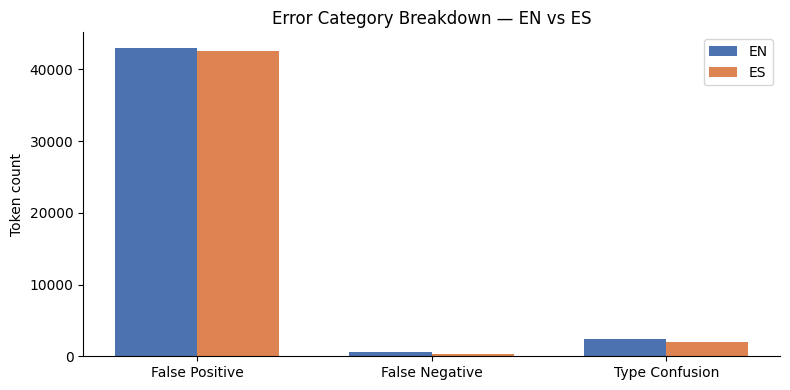

In [ ]:
breakdown = pd.DataFrame({
    'Error Type':    ['False Positive', 'False Negative', 'Type Confusion'],
    'EN Count':      [len(en_errors['false_positive']),
                      len(en_errors['false_negative']),
                      len(en_errors['type_confusion'])],
    'ES Count':      [len(es_errors['false_positive']),
                      len(es_errors['false_negative']),
                      len(es_errors['type_confusion'])],
})
print('Error counts by category:')
display(breakdown)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(breakdown))
w = 0.35
ax.bar([i - w/2 for i in x], breakdown['EN Count'], width=w, label='EN', color='#4C72B0')
ax.bar([i + w/2 for i in x], breakdown['ES Count'], width=w, label='ES', color='#DD8452')
ax.set_xticks(list(x))
ax.set_xticklabels(breakdown['Error Type'])
ax.set_ylabel('Token count')
ax.set_title('Error Category Breakdown — EN vs ES')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(str(REPO_ROOT / 'outputs' / 'results' / 'error_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def show_errors(errors, category, n=10, lang='EN'):
    items = errors[category][:n]
    if not items:
        print(f'No {category} errors found.')
        return
    rows = [{'Token': e['token'], 'True': e['true'], 'Pred': e['pred'],
             'Context (truncated)': e['context'][:80]} for e in items]
    df = pd.DataFrame(rows)
    print(f'\n{lang} — {category.replace("_", " ").title()} (first {len(items)}):')
    display(df)


show_errors(en_errors, 'false_negative',  n=10, lang='EN')
show_errors(en_errors, 'false_positive',  n=10, lang='EN')
show_errors(en_errors, 'type_confusion',  n=10, lang='EN')


EN — False Negative (first 10):


,Token,True,Pred,Context (truncated)
0,with,I-DIS,O,CLINICAL EVOLUTION After being assessed in the...
1,of,I-PRO,O,Male patient aged 34 years. Personal history: ...
2,pre-ESWL.,B-PRO,O,"14 days after lithotripsy, the haematoma was d..."
3,IVs(cardiogenic,B-DIS,O,DIAGNOSIS Death due to late prosthetic infecti...
4,with,I-SYM,O,Myopia of -13.00 dioptres (-2 to 90º) in the r...
5,an,I-SYM,O,Myopia of -13.00 dioptres (-2 to 90º) in the r...
6,increased,I-SYM,O,Myopia of -13.00 dioptres (-2 to 90º) in the r...
7,latency,I-SYM,O,Myopia of -13.00 dioptres (-2 to 90º) in the r...
8,period.,I-SYM,O,Myopia of -13.00 dioptres (-2 to 90º) in the r...
9,or,I-SYM,O,"At 10 months of age, there was significant psy..."



EN — False Positive (first 10):


,Token,True,Pred,Context (truncated)
0,diabetes,O,B-DIS,A 73-year-old man on his first visit to our de...
1,"mellitus,",O,I-DIS,A 73-year-old man on his first visit to our de...
2,ischaemic,O,B-DIS,A 73-year-old man on his first visit to our de...
3,heart,O,I-DIS,A 73-year-old man on his first visit to our de...
4,"disease,",O,I-DIS,A 73-year-old man on his first visit to our de...
5,smoking,O,B-DIS,A 73-year-old man on his first visit to our de...
6,allergies,O,B-DIS,A 73-year-old man on his first visit to our de...
7,to,O,I-DIS,A 73-year-old man on his first visit to our de...
8,medication.,O,I-DIS,A 73-year-old man on his first visit to our de...
9,laboratory,O,B-PRO,A 73-year-old man on his first visit to our de...



EN — Type Confusion (first 10):


,Token,True,Pred,Context (truncated)
0,injecting,I-DIS,B-DIS,History No known drug allergies. Toxic habits:...
1,fine,I-DIS,B-SYM,CLINICAL EVOLUTION After being assessed in the...
2,calibre,I-DIS,I-SYM,CLINICAL EVOLUTION After being assessed in the...
3,of,I-DIS,I-SYM,CLINICAL EVOLUTION After being assessed in the...
4,the,I-DIS,I-SYM,CLINICAL EVOLUTION After being assessed in the...
5,entire,I-DIS,I-SYM,CLINICAL EVOLUTION After being assessed in the...
6,coronary,I-DIS,I-SYM,CLINICAL EVOLUTION After being assessed in the...
7,"tree,",I-DIS,I-SYM,CLINICAL EVOLUTION After being assessed in the...
8,vasospastic,I-DIS,B-DIS,DIAGNOSIS Recurrent vasospastic angina refract...
9,vasospastic,I-DIS,B-DIS,DIAGNOSIS Recurrent vasospastic angina refract...


In [ ]:
show_errors(es_errors, 'false_negative',  n=10, lang='ES')
show_errors(es_errors, 'false_positive',  n=10, lang='ES')
show_errors(es_errors, 'type_confusion',  n=10, lang='ES')


ES — False Negative (first 10):


,Token,True,Pred,Context (truncated)
0,de,I-DIS,O,Se realiza una angiofluoresceingrafía (AFG) en...
1,esta,I-DIS,O,Se realiza una angiofluoresceingrafía (AFG) en...
2,cefalosporina,B-PRO,O,OBSERVACIÓN CLÍNICA En el último ingreso antes...
3,de,I-PRO,O,OBSERVACIÓN CLÍNICA En el último ingreso antes...
4,tercera,I-PRO,O,OBSERVACIÓN CLÍNICA En el último ingreso antes...
5,generación,I-PRO,O,OBSERVACIÓN CLÍNICA En el último ingreso antes...
6,estadio,I-DIS,O,Varón de 76 años afecto de ERC estadio 4 secun...
7,4,I-DIS,O,Varón de 76 años afecto de ERC estadio 4 secun...
8,de,I-DIS,O,"ANTECEDENTES, ENFERMEDAD ACTUAL Y EXPLORACIÓN ..."
9,40o,I-SYM,O,"15/11/16 Instala síndrome confusional, fiebre ..."



ES — False Positive (first 10):


,Token,True,Pred,Context (truncated)
0,fallecido,O,B-SYM,Niño de 13 años sin antecedentes personales de...
1,síntomas,O,B-SYM,Niño de 13 años sin antecedentes personales de...
2,miccionales,O,I-SYM,Niño de 13 años sin antecedentes personales de...
3,"(disuria,",O,B-SYM,Niño de 13 años sin antecedentes personales de...
4,polaquiuria),O,B-SYM,Niño de 13 años sin antecedentes personales de...
5,tira,O,B-PRO,Niño de 13 años sin antecedentes personales de...
6,reactiva,O,I-PRO,Niño de 13 años sin antecedentes personales de...
7,de,O,I-PRO,Niño de 13 años sin antecedentes personales de...
8,orina,O,I-PRO,Niño de 13 años sin antecedentes personales de...
9,fue,O,I-SYM,Niño de 13 años sin antecedentes personales de...



ES — Type Confusion (first 10):


,Token,True,Pred,Context (truncated)
0,subretiniana,B-DIS,I-SYM,Se realiza una angiofluoresceingrafía (AFG) en...
1,"hemorragia,",I-DIS,B-DIS,Se realiza una angiofluoresceingrafía (AFG) en...
2,(MNV),B-DIS,I-DIS,Se realiza una angiofluoresceingrafía (AFG) en...
3,sangre,B-DIS,B-SYM,"Un mes después de este procedimiento, acude de..."
4,en,I-DIS,I-SYM,"Un mes después de este procedimiento, acude de..."
5,el,I-DIS,I-SYM,"Un mes después de este procedimiento, acude de..."
6,ámbito,I-DIS,I-SYM,"Un mes después de este procedimiento, acude de..."
7,macular,I-DIS,I-SYM,"Un mes después de este procedimiento, acude de..."
8,estenosis,B-PRO,B-DIS,Antecedentes personales Paciente varón de 81 a...
9,aórtica,I-PRO,I-DIS,Antecedentes personales Paciente varón de 81 a...


In [ ]:
# Normalise by total entity tokens in each test set
def total_entity_tokens(label_seqs):
    return sum(1 for seq in label_seqs for l in seq if l != 'O')

en_entity_total = total_entity_tokens(en_true)
es_entity_total = total_entity_tokens(es_true)

rate_df = pd.DataFrame({
    'Error Type':   ['False Positive', 'False Negative', 'Type Confusion'],
    'EN Rate':      [
        round(len(en_errors['false_positive']) / max(en_entity_total, 1), 4),
        round(len(en_errors['false_negative']) / max(en_entity_total, 1), 4),
        round(len(en_errors['type_confusion']) / max(en_entity_total, 1), 4),
    ],
    'ES Rate':      [
        round(len(es_errors['false_positive']) / max(es_entity_total, 1), 4),
        round(len(es_errors['false_negative']) / max(es_entity_total, 1), 4),
        round(len(es_errors['type_confusion']) / max(es_entity_total, 1), 4),
    ],
})

print('Error rates (normalised by entity token count):')
display(rate_df)

Error rates (normalised by entity token count):


,Error Type,EN Rate,ES Rate
0,False Positive,2.6860,2.7135
1,False Negative,0.0330,0.0231
2,Type Confusion,0.1487,0.1273
